# Task 1: Preprocess and Explore the Data

**Objective:** Load, clean, and understand the historical financial data for TSLA, BND, and SPY to prepare it for time series forecasting models.

**Assets:**
- **TSLA** (Tesla) - High risk, high potential return
- **BND** (Vanguard Total Bond Market ETF) - Low risk, stability and income
- **SPY** (S&P 500 ETF) - Moderate risk, broad market exposure

**Period:** January 1, 2015 to June 30, 2026

## 1. Setup and Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("All imports successful.")

All imports successful.


## 2. Extract Historical Financial Data

In [2]:
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

data = {}
for ticker in tickers:
    print(f"Fetching {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
    data[ticker] = df
    print(f"  {ticker}: {len(df)} rows, from {df.index.min().date()} to {df.index.max().date()}")

print("\nData extraction complete.")

Fetching TSLA...


[*********************100%***********************]  1 of 1 completed

  TSLA: 2888 rows, from 2015-01-02 to 2026-06-29
Fetching BND...


[*********************100%***********************]  1 of 1 completed

  BND: 2888 rows, from 2015-01-02 to 2026-06-29
Fetching SPY...


[*********************100%***********************]  1 of 1 completed

  SPY: 2888 rows, from 2015-01-02 to 2026-06-29

Data extraction complete.


In [3]:
for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"{ticker} - Shape: {data[ticker].shape}")
    print(f"{'='*60}")
    print(data[ticker].head())
    print(f"\nColumn dtypes:\n{data[ticker].dtypes}")


TSLA - Shape: (2888, 6)
Price       Adj Close      Close       High        Low       Open    Volume
Date                                                                       
2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500

Column dtypes:
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

BND - Shape: (2888, 6)
Price       Adj Close      Close       High        Low       Open   Volume
Date                                                                      
2015-01-02  59.405426  82.650002  82.690002  82.419998  82.430000  2218800
2015-01-05  59.577866  82.889999

## 3. Data Cleaning and Understanding

### 3.1 Basic Statistics

In [4]:
for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"{ticker} - Descriptive Statistics")
    print(f"{'='*60}")
    print(data[ticker].describe().round(2))


TSLA - Descriptive Statistics
Price  Adj Close    Close     High      Low     Open        Volume
count    2888.00  2888.00  2888.00  2888.00  2888.00  2.888000e+03
mean      148.77   148.77   151.99   145.42   148.80  1.087922e+08
std       138.90   138.90   141.85   135.87   138.98  7.082549e+07
min         9.58     9.58    10.33     9.40     9.49  1.062000e+07
25%        18.39    18.39    18.67    18.02    18.39  6.548325e+07
50%       133.44   133.44   136.05   125.83   131.50  9.033615e+07
75%       251.93   251.93   257.49   245.83   251.68  1.261204e+08
max       489.88   489.88   498.83   485.33   489.88  9.140820e+08

BND - Descriptive Statistics
Price  Adj Close    Close     High      Low     Open       Volume
count    2888.00  2888.00  2888.00  2888.00  2888.00      2888.00
mean       66.50    79.33    79.44    79.21    79.33   4653785.80
std         4.71     5.31     5.30     5.32     5.31   3017703.95
min        58.73    68.04    68.38    67.99    68.08         0.00
25%   

### 3.2 Missing Values

In [5]:
for ticker in tickers:
    missing = data[ticker].isnull().sum()
    total = len(data[ticker])
    print(f"\n{ticker} - Missing values (out of {total} rows):")
    print(missing)
    if missing.sum() > 0:
        print(f"  -> Total missing entries: {missing.sum()}")


TSLA - Missing values (out of 2888 rows):
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

BND - Missing values (out of 2888 rows):
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

SPY - Missing values (out of 2888 rows):
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [6]:
for ticker in tickers:
    if data[ticker].isnull().sum().sum() > 0:
        print(f"Filling missing values for {ticker} using forward-fill then back-fill...")
        data[ticker] = data[ticker].ffill().bfill()
        remaining = data[ticker].isnull().sum().sum()
        print(f"  Remaining missing values: {remaining}")
    else:
        print(f"{ticker}: No missing values.")

TSLA: No missing values.
BND: No missing values.
SPY: No missing values.


### 3.3 Data Type Verification

In [7]:
for ticker in tickers:
    df = data[ticker]
    print(f"\n{ticker}:")
    print(f"  Index type: {type(df.index).__name__}, dtype: {df.index.dtype}")
    print(f"  Index is monotonic increasing: {df.index.is_monotonic_increasing}")
    for col in df.columns:
        print(f"  {col}: {df[col].dtype}")


TSLA:
  Index type: DatetimeIndex, dtype: datetime64[s]
  Index is monotonic increasing: True
  Adj Close: float64
  Close: float64
  High: float64
  Low: float64
  Open: float64
  Volume: int64

BND:
  Index type: DatetimeIndex, dtype: datetime64[s]
  Index is monotonic increasing: True
  Adj Close: float64
  Close: float64
  High: float64
  Low: float64
  Open: float64
  Volume: int64

SPY:
  Index type: DatetimeIndex, dtype: datetime64[s]
  Index is monotonic increasing: True
  Adj Close: float64
  Close: float64
  High: float64
  Low: float64
  Open: float64
  Volume: int64


### 3.4 Create Combined Close Price DataFrame and Daily Returns

In [8]:
close_prices = pd.DataFrame({
    ticker: data[ticker]['Close'] for ticker in tickers
})
close_prices.index.name = 'Date'

daily_returns = close_prices.pct_change().dropna()

print("Close Prices DataFrame:")
print(close_prices.head())
print(f"\nShape: {close_prices.shape}")
print(f"\nDaily Returns DataFrame:")
print(daily_returns.head())
print(f"\nShape: {daily_returns.shape}")

Close Prices DataFrame:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  82.650002  205.429993
2015-01-05  14.006000  82.889999  201.720001
2015-01-06  14.085333  83.129997  199.820007
2015-01-07  14.063333  83.180000  202.309998
2015-01-08  14.041333  83.050003  205.899994

Shape: (2888, 3)

Daily Returns DataFrame:
                TSLA       BND       SPY
Date                                    
2015-01-05 -0.042041  0.002904 -0.018060
2015-01-06  0.005664  0.002895 -0.009419
2015-01-07 -0.001562  0.000602  0.012461
2015-01-08 -0.001564 -0.001563  0.017745
2015-01-09 -0.018802  0.001686 -0.008014

Shape: (2887, 3)


### 3.5 Save Processed Data

In [9]:
import os
processed_dir = os.path.join('..', 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

for ticker in tickers:
    data[ticker].to_csv(os.path.join(processed_dir, f'{ticker}_raw.csv'))

close_prices.to_csv(os.path.join(processed_dir, 'close_prices.csv'))
daily_returns.to_csv(os.path.join(processed_dir, 'daily_returns.csv'))

print("Data saved to data/processed/")

Data saved to data/processed/


## 4. Exploratory Data Analysis (EDA)

### 4.1 Closing Price Over Time

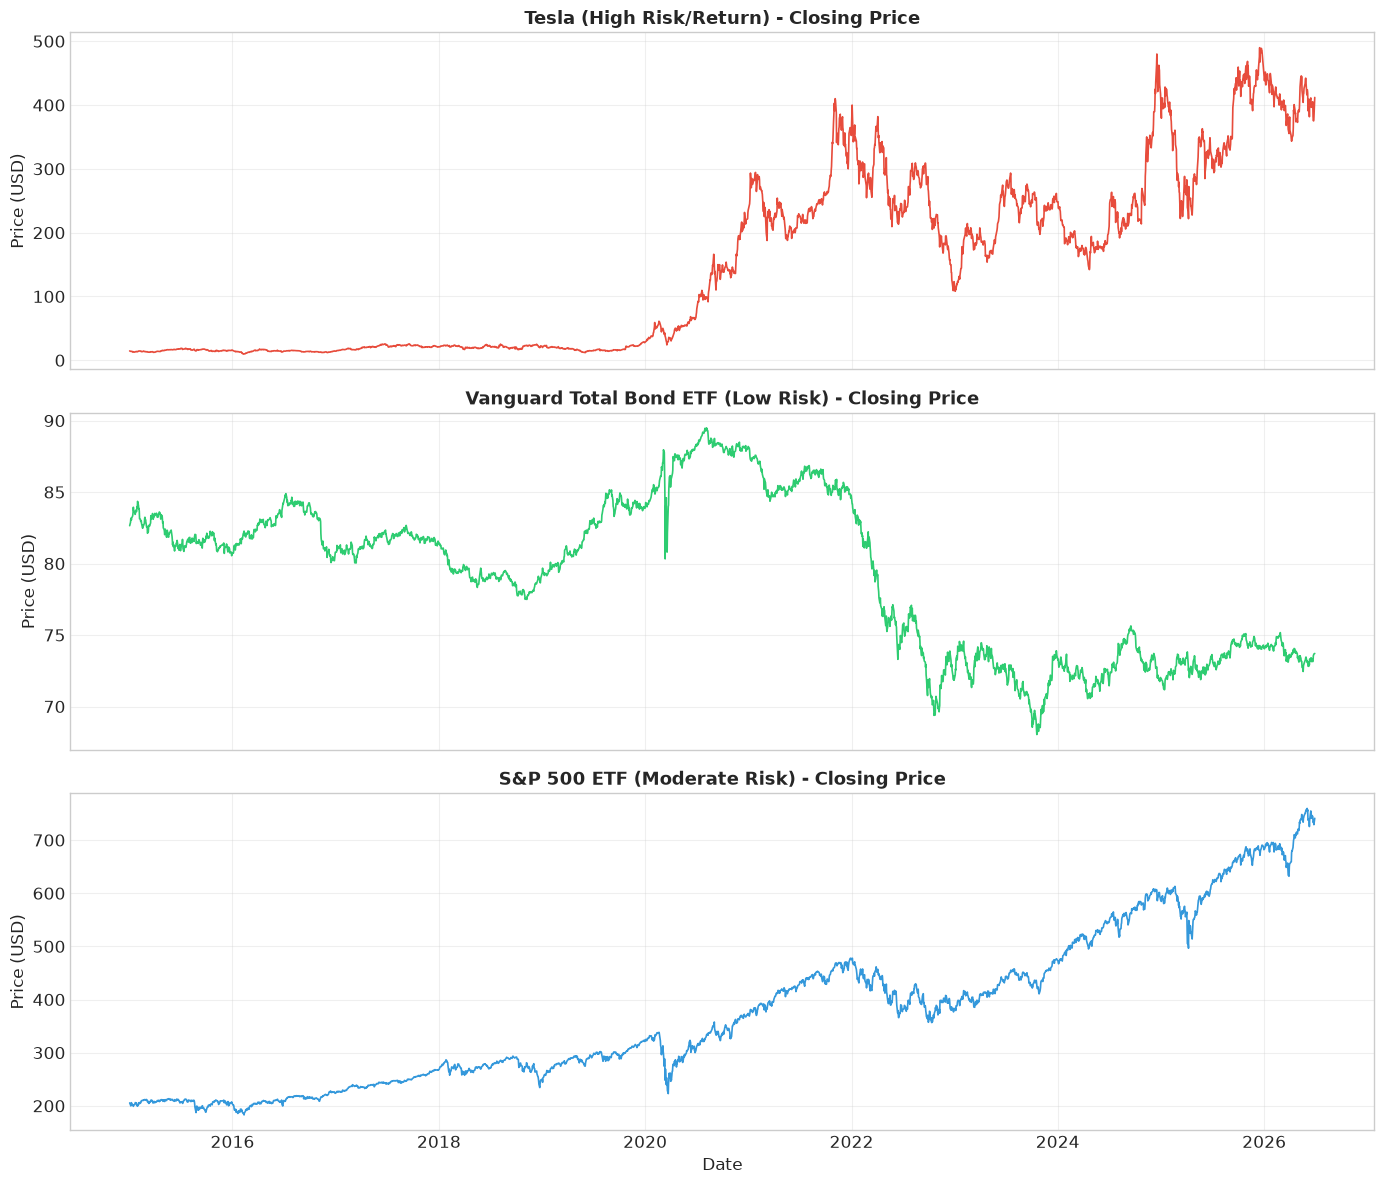

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

colors = {'TSLA': '#e74c3c', 'BND': '#2ecc71', 'SPY': '#3498db'}
descriptions = {
    'TSLA': 'Tesla (High Risk/Return)',
    'BND': 'Vanguard Total Bond ETF (Low Risk)',
    'SPY': 'S&P 500 ETF (Moderate Risk)'
}

for ax, ticker in zip(axes, tickers):
    ax.plot(close_prices.index, close_prices[ticker], color=colors[ticker], linewidth=1.2)
    ax.set_title(f'{descriptions[ticker]} - Closing Price', fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'closing_prices.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Normalized Price Comparison

To compare relative performance across assets with very different price scales, we normalize all prices to start at 100.

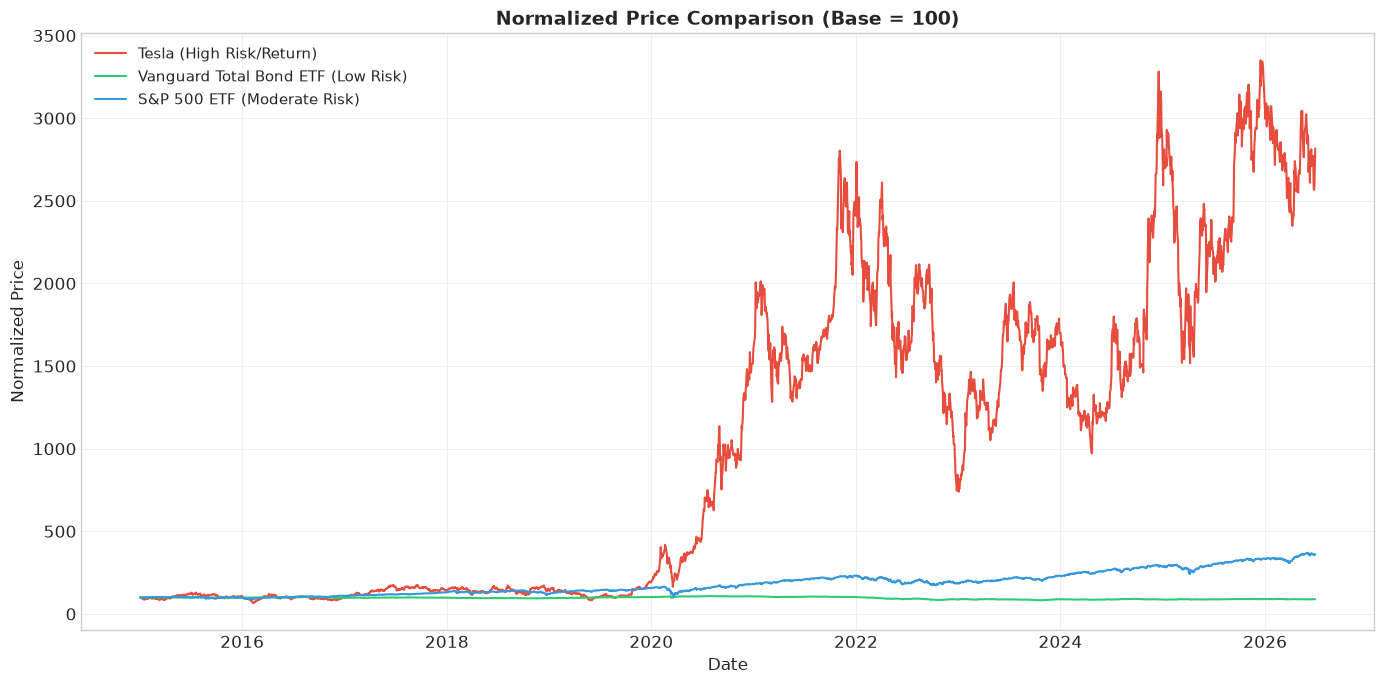

In [11]:
normalized = close_prices / close_prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))
for ticker in tickers:
    ax.plot(normalized.index, normalized[ticker], label=descriptions[ticker],
            color=colors[ticker], linewidth=1.5)

ax.set_title('Normalized Price Comparison (Base = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'normalized_prices.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Daily Percentage Change (Volatility)

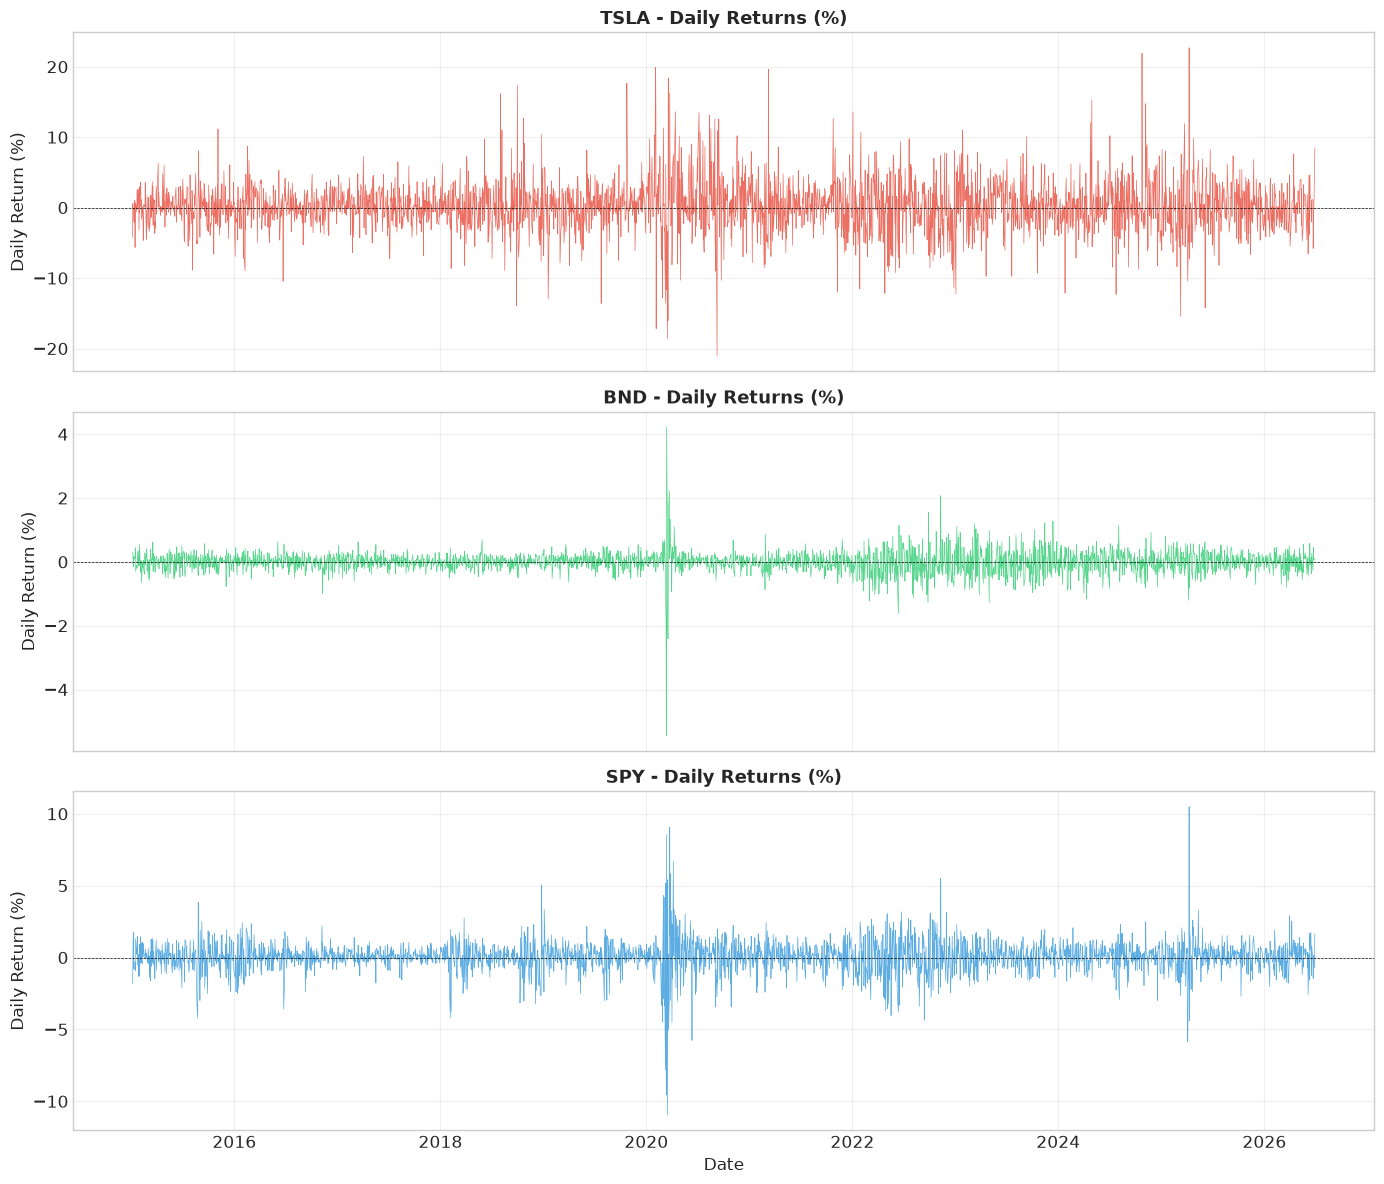

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(daily_returns.index, daily_returns[ticker] * 100, color=colors[ticker],
            linewidth=0.5, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f'{ticker} - Daily Returns (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Daily Return (%)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'daily_returns_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

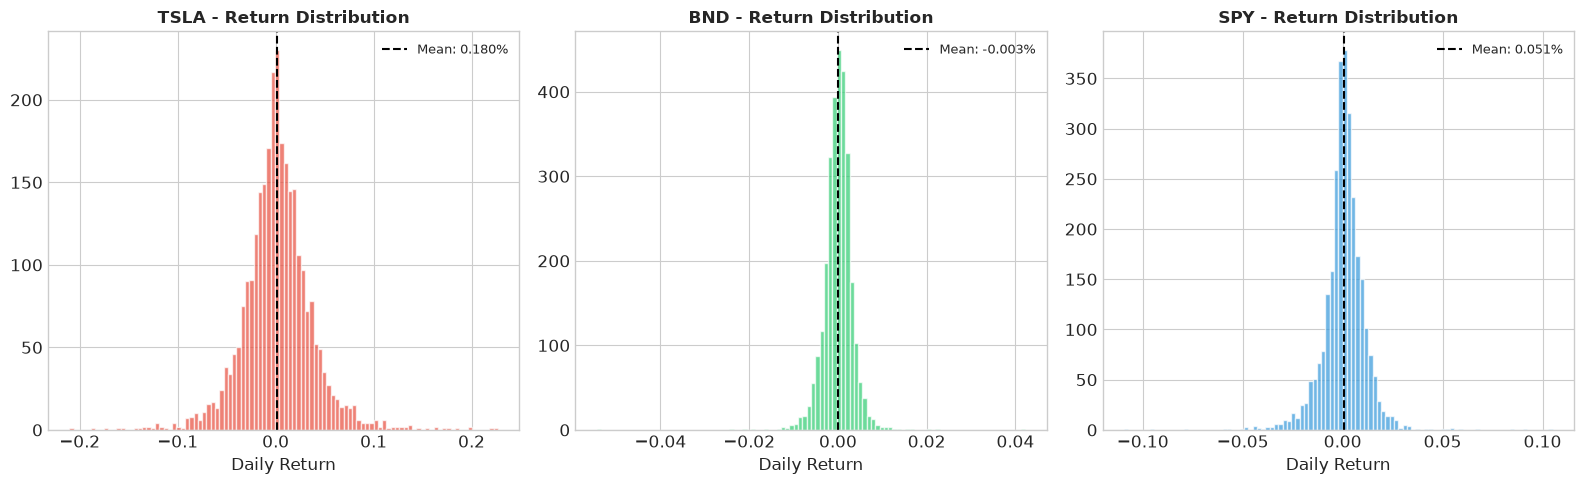


Daily Returns Summary Statistics:
              TSLA          BND          SPY
count  2887.000000  2887.000000  2887.000000
mean      0.001803    -0.000034     0.000507
std       0.036018     0.003383     0.011163
min      -0.210628    -0.054385    -0.109424
25%      -0.016643    -0.001635    -0.003772
50%       0.001216     0.000119     0.000603
75%       0.019456     0.001715     0.005920
max       0.226900     0.042201     0.105019


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ticker in zip(axes, tickers):
    daily_returns[ticker].hist(bins=100, ax=ax, color=colors[ticker], alpha=0.7, edgecolor='white')
    ax.axvline(daily_returns[ticker].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {daily_returns[ticker].mean()*100:.3f}%')
    ax.set_title(f'{ticker} - Return Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'return_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nDaily Returns Summary Statistics:")
print(daily_returns.describe().round(6))

### 4.4 Rolling Mean and Standard Deviation (Volatility Analysis)

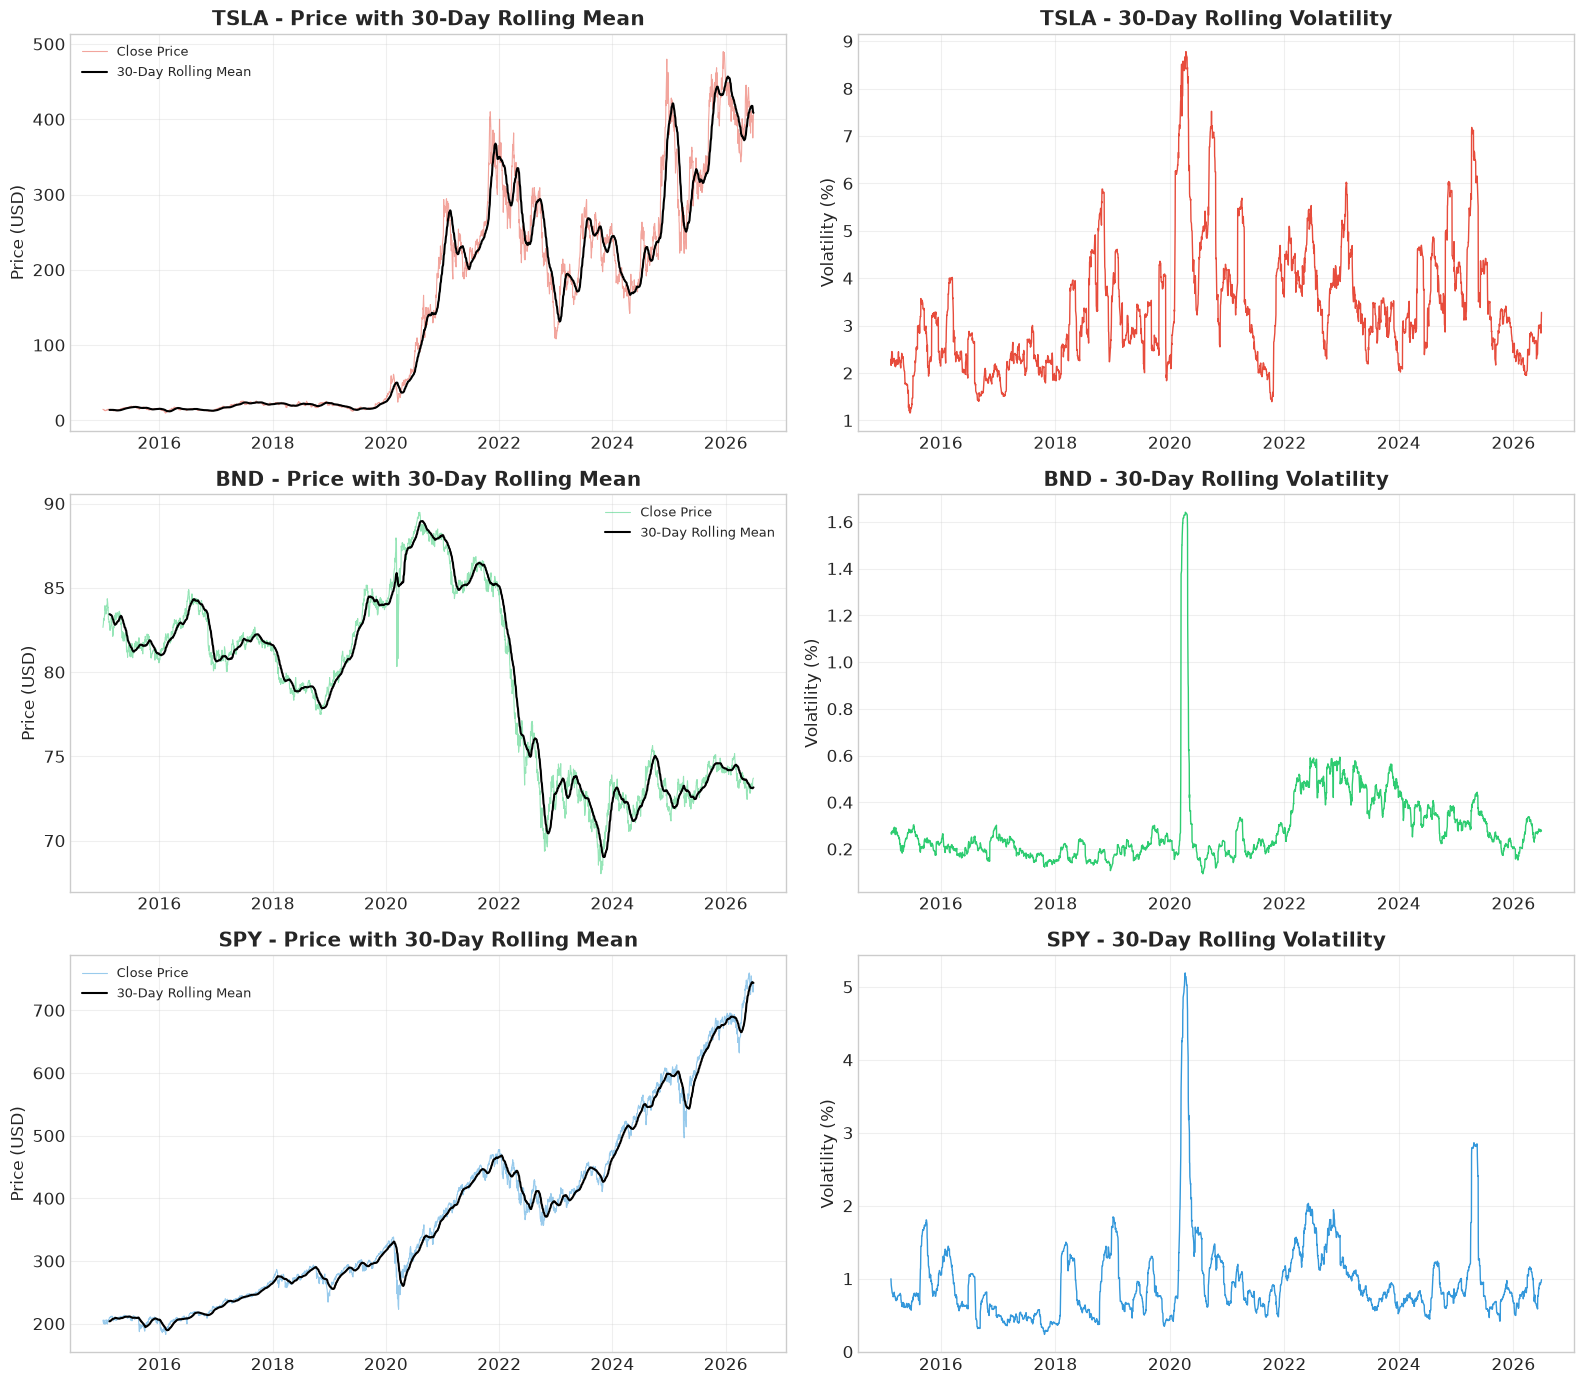

In [14]:
window = 30  # 30-day rolling window

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for i, ticker in enumerate(tickers):
    rolling_mean = close_prices[ticker].rolling(window=window).mean()
    rolling_std = daily_returns[ticker].rolling(window=window).std()

    # Rolling Mean of Close Price
    axes[i, 0].plot(close_prices.index, close_prices[ticker], alpha=0.5,
                     label='Close Price', color=colors[ticker], linewidth=0.8)
    axes[i, 0].plot(rolling_mean.index, rolling_mean, label=f'{window}-Day Rolling Mean',
                     color='black', linewidth=1.5)
    axes[i, 0].set_title(f'{ticker} - Price with {window}-Day Rolling Mean', fontweight='bold')
    axes[i, 0].set_ylabel('Price (USD)')
    axes[i, 0].legend(fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)

    # Rolling Std of Returns
    axes[i, 1].plot(rolling_std.index, rolling_std * 100, color=colors[ticker], linewidth=1)
    axes[i, 1].set_title(f'{ticker} - {window}-Day Rolling Volatility', fontweight='bold')
    axes[i, 1].set_ylabel('Volatility (%)')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'rolling_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Outlier Detection

In [15]:
print("Outlier Analysis (returns beyond 2 standard deviations):\n")

outlier_summary = {}
for ticker in tickers:
    returns = daily_returns[ticker]
    mean_ret = returns.mean()
    std_ret = returns.std()
    threshold = 2 * std_ret

    outliers = returns[abs(returns - mean_ret) > threshold]
    outlier_summary[ticker] = outliers

    print(f"{ticker}:")
    print(f"  Mean return: {mean_ret*100:.4f}%")
    print(f"  Std deviation: {std_ret*100:.4f}%")
    print(f"  Outlier threshold: +/-{threshold*100:.4f}%")
    print(f"  Number of outlier days: {len(outliers)} ({len(outliers)/len(returns)*100:.1f}% of trading days)")
    print(f"  Largest positive return: {returns.max()*100:.2f}% on {returns.idxmax().date()}")
    print(f"  Largest negative return: {returns.min()*100:.2f}% on {returns.idxmin().date()}")
    print()

Outlier Analysis (returns beyond 2 standard deviations):

TSLA:
  Mean return: 0.1803%
  Std deviation: 3.6018%
  Outlier threshold: +/-7.2037%
  Number of outlier days: 152 (5.3% of trading days)
  Largest positive return: 22.69% on 2025-04-09
  Largest negative return: -21.06% on 2020-09-08

BND:
  Mean return: -0.0034%
  Std deviation: 0.3383%
  Outlier threshold: +/-0.6765%
  Number of outlier days: 108 (3.7% of trading days)
  Largest positive return: 4.22% on 2020-03-13
  Largest negative return: -5.44% on 2020-03-12

SPY:
  Mean return: 0.0507%
  Std deviation: 1.1163%
  Outlier threshold: +/-2.2326%
  Number of outlier days: 132 (4.6% of trading days)
  Largest positive return: 10.50% on 2025-04-09
  Largest negative return: -10.94% on 2020-03-16



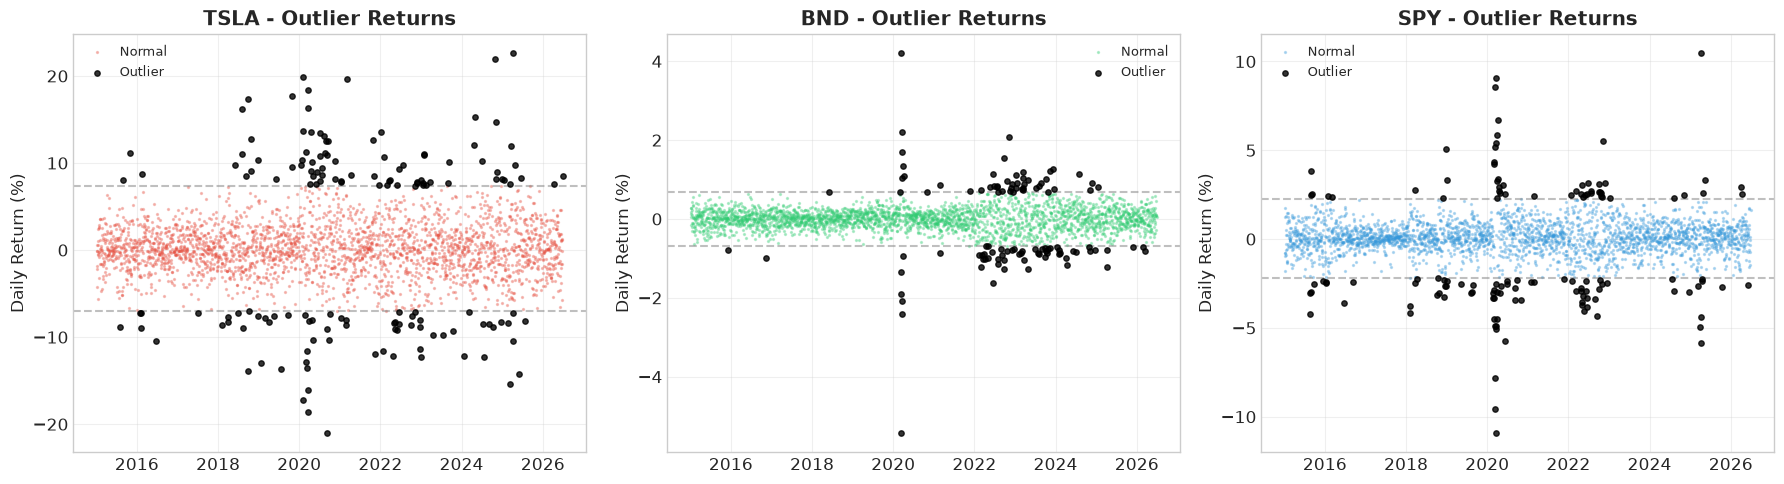

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, tickers):
    returns = daily_returns[ticker]
    mean_ret = returns.mean()
    std_ret = returns.std()

    normal_mask = abs(returns - mean_ret) <= 2 * std_ret
    outlier_mask = ~normal_mask

    ax.scatter(returns.index[normal_mask], returns[normal_mask] * 100,
               s=2, alpha=0.3, color=colors[ticker], label='Normal')
    ax.scatter(returns.index[outlier_mask], returns[outlier_mask] * 100,
               s=15, alpha=0.8, color='black', label='Outlier', zorder=5)
    ax.axhline(y=(mean_ret + 2*std_ret)*100, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=(mean_ret - 2*std_ret)*100, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{ticker} - Outlier Returns', fontweight='bold')
    ax.set_ylabel('Daily Return (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'outliers.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Top Extreme Return Days

In [17]:
for ticker in tickers:
    returns = daily_returns[ticker]
    print(f"\n{'='*50}")
    print(f"{ticker} - Top 5 Most Extreme Return Days")
    print(f"{'='*50}")

    extreme = returns.abs().nlargest(5)
    for date, _ in extreme.items():
        ret = returns.loc[date]
        direction = 'UP' if ret > 0 else 'DOWN'
        print(f"  {date.date()}: {ret*100:+.2f}% ({direction})")


TSLA - Top 5 Most Extreme Return Days
  2025-04-09: +22.69% (UP)
  2024-10-24: +21.92% (UP)
  2020-09-08: -21.06% (DOWN)
  2020-02-03: +19.89% (UP)
  2021-03-09: +19.64% (UP)

BND - Top 5 Most Extreme Return Days
  2020-03-12: -5.44% (DOWN)
  2020-03-13: +4.22% (UP)
  2020-03-18: -2.41% (DOWN)
  2020-03-23: +2.21% (UP)
  2022-11-10: +2.07% (UP)

SPY - Top 5 Most Extreme Return Days
  2020-03-16: -10.94% (DOWN)
  2025-04-09: +10.50% (UP)
  2020-03-12: -9.57% (DOWN)
  2020-03-24: +9.06% (UP)
  2020-03-13: +8.55% (UP)


### 4.7 Correlation Analysis

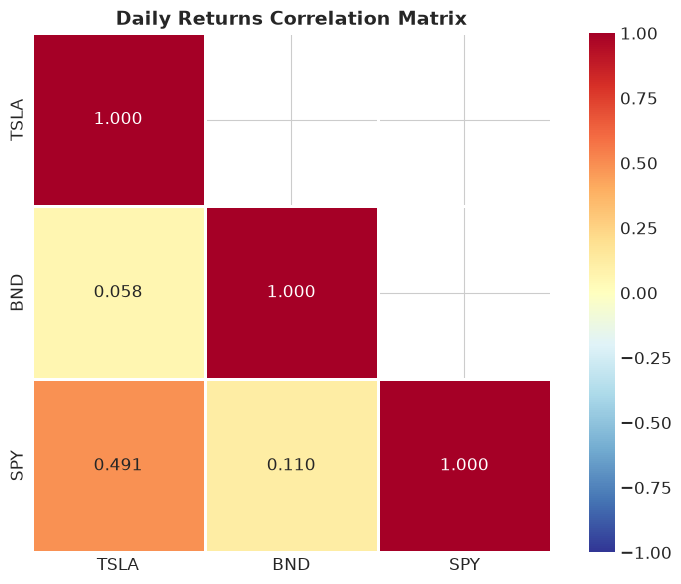


Correlation Matrix:
        TSLA     BND     SPY
TSLA  1.0000  0.0584  0.4915
BND   0.0584  1.0000  0.1099
SPY   0.4915  0.1099  1.0000


In [18]:
corr_matrix = daily_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.3f', square=True, linewidths=2, ax=ax,
            vmin=-1, vmax=1, mask=mask)
ax.set_title('Daily Returns Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(4))

## 5. Seasonality and Trend Analysis

### 5.1 Augmented Dickey-Fuller (ADF) Stationarity Test

**Null Hypothesis (H0):** The time series has a unit root (non-stationary).

**Alternative Hypothesis (H1):** The time series is stationary.

If p-value < 0.05, we reject H0 and conclude the series is stationary.

In [19]:
def run_adf_test(series, name):
    """Run ADF test and return results as a dictionary."""
    result = adfuller(series.dropna(), autolag='AIC')
    is_stationary = result[1] < 0.05
    return {
        'Series': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 6),
        'Lags Used': result[2],
        'Observations': result[3],
        'Critical (1%)': round(result[4]['1%'], 4),
        'Critical (5%)': round(result[4]['5%'], 4),
        'Critical (10%)': round(result[4]['10%'], 4),
        'Stationary': 'Yes' if is_stationary else 'No'
    }

adf_results = []

print("Augmented Dickey-Fuller Test Results")
print("=" * 70)

# Test closing prices (expected: non-stationary)
print("\n--- Closing Prices ---")
for ticker in tickers:
    result = run_adf_test(close_prices[ticker], f'{ticker} Close Price')
    adf_results.append(result)
    print(f"\n{ticker}:")
    print(f"  ADF Statistic: {result['ADF Statistic']}")
    print(f"  p-value: {result['p-value']}")
    print(f"  Stationary: {result['Stationary']}")

# Test daily returns (expected: stationary)
print("\n--- Daily Returns ---")
for ticker in tickers:
    result = run_adf_test(daily_returns[ticker], f'{ticker} Daily Returns')
    adf_results.append(result)
    print(f"\n{ticker}:")
    print(f"  ADF Statistic: {result['ADF Statistic']}")
    print(f"  p-value: {result['p-value']}")
    print(f"  Stationary: {result['Stationary']}")

Augmented Dickey-Fuller Test Results

--- Closing Prices ---

TSLA:
  ADF Statistic: -1.0696
  p-value: 0.727042
  Stationary: No

BND:
  ADF Statistic: -1.0362
  p-value: 0.739841
  Stationary: No



SPY:
  ADF Statistic: 0.9918
  p-value: 0.994179
  Stationary: No

--- Daily Returns ---

TSLA:
  ADF Statistic: -53.9719
  p-value: 0.0
  Stationary: Yes

BND:
  ADF Statistic: -15.2964
  p-value: 0.0
  Stationary: Yes



SPY:
  ADF Statistic: -17.4905
  p-value: 0.0
  Stationary: Yes


In [20]:
adf_df = pd.DataFrame(adf_results)
print("\nComplete ADF Test Results:")
adf_df


Complete ADF Test Results:


,Series,ADF Statistic,p-value,Lags Used,Observations,Critical (1%),Critical (5%),Critical (10%),Stationary
0,TSLA Close Price,-1.0696,0.727042,27,2860,-3.4326,-2.8626,-2.5673,No
1,BND Close Price,-1.0362,0.739841,13,2874,-3.4326,-2.8625,-2.5673,No
2,SPY Close Price,0.9918,0.994179,9,2878,-3.4326,-2.8625,-2.5673,No
3,TSLA Daily Returns,-53.9719,0.000000,0,2886,-3.4326,-2.8625,-2.5673,Yes
4,BND Daily Returns,-15.2964,0.000000,12,2874,-3.4326,-2.8625,-2.5673,Yes
5,SPY Daily Returns,-17.4905,0.000000,8,2878,-3.4326,-2.8625,-2.5673,Yes


### 5.2 Interpretation of Stationarity Results

**Closing Prices:** As expected, the closing prices for all three assets are **non-stationary** (p-value > 0.05). This means the series has a trend and its statistical properties (mean, variance) change over time. This is typical for asset prices which follow a random walk pattern.

**Daily Returns:** The daily returns are **stationary** (p-value < 0.05). After differencing (computing returns), the trend is removed and the series fluctuates around a constant mean.

**Implications for ARIMA:**
- Since closing prices are non-stationary, we need differencing (d >= 1) in the ARIMA(p, d, q) model to make the series stationary before modeling.
- The stationarity of daily returns confirms that first-order differencing is sufficient (d=1).
- This is a prerequisite for ARIMA models, which assume the input series is stationary.

### 5.3 Seasonal Decomposition

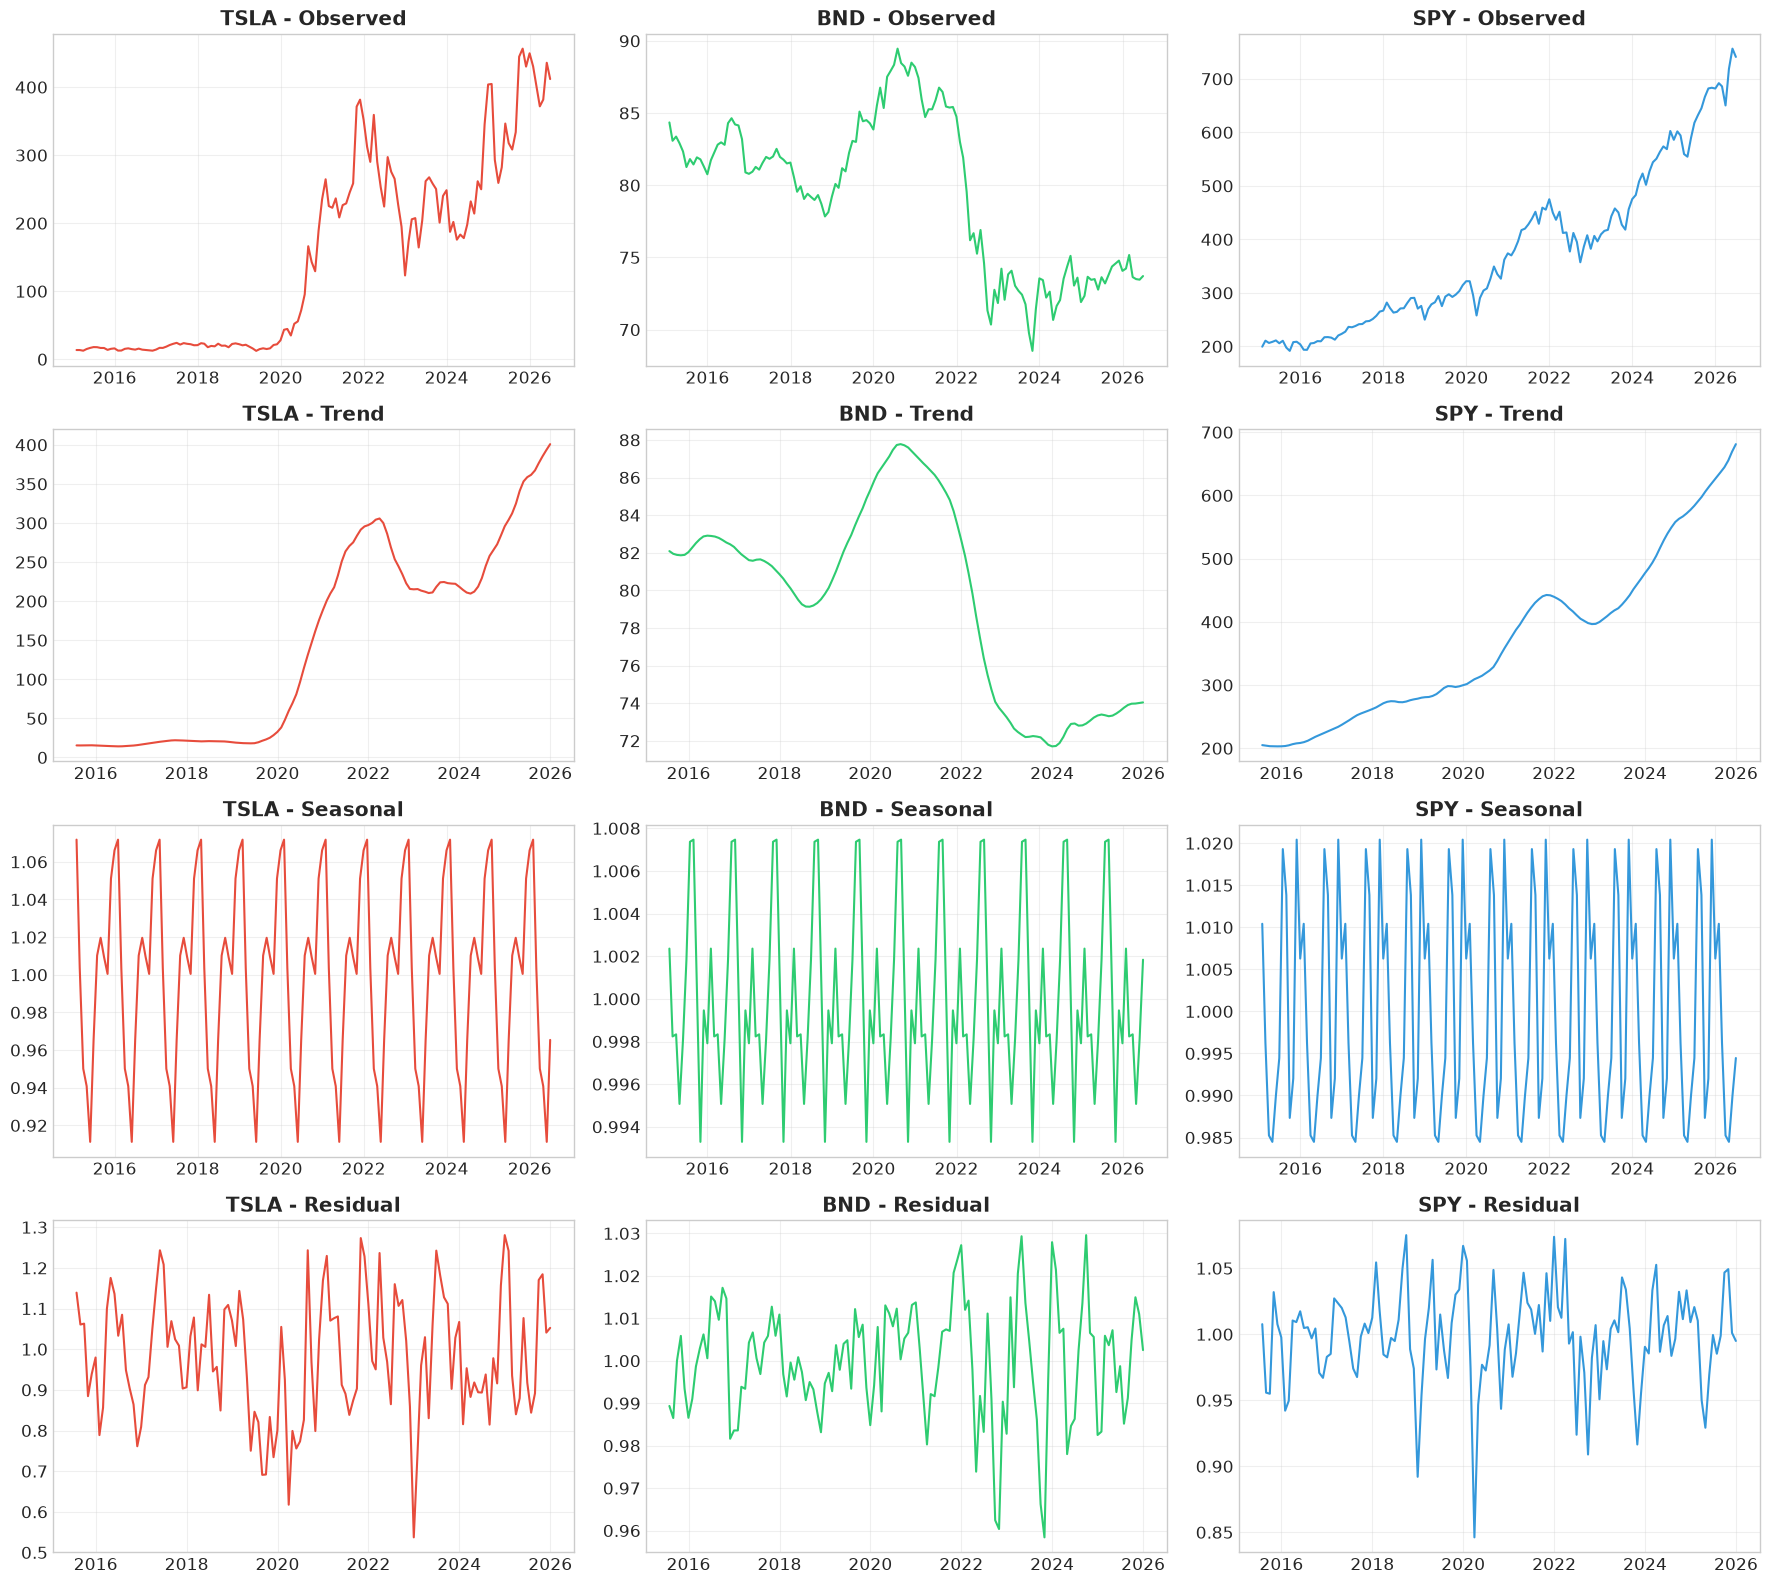

In [21]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for j, ticker in enumerate(tickers):
    monthly_prices = close_prices[ticker].resample('ME').last().dropna()
    decomposition = seasonal_decompose(monthly_prices, model='multiplicative', period=12)

    axes[0, j].plot(decomposition.observed, color=colors[ticker])
    axes[0, j].set_title(f'{ticker} - Observed', fontweight='bold')
    axes[0, j].grid(True, alpha=0.3)

    axes[1, j].plot(decomposition.trend, color=colors[ticker])
    axes[1, j].set_title(f'{ticker} - Trend', fontweight='bold')
    axes[1, j].grid(True, alpha=0.3)

    axes[2, j].plot(decomposition.seasonal, color=colors[ticker])
    axes[2, j].set_title(f'{ticker} - Seasonal', fontweight='bold')
    axes[2, j].grid(True, alpha=0.3)

    axes[3, j].plot(decomposition.resid, color=colors[ticker])
    axes[3, j].set_title(f'{ticker} - Residual', fontweight='bold')
    axes[3, j].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'seasonal_decomposition.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Monthly Return Patterns

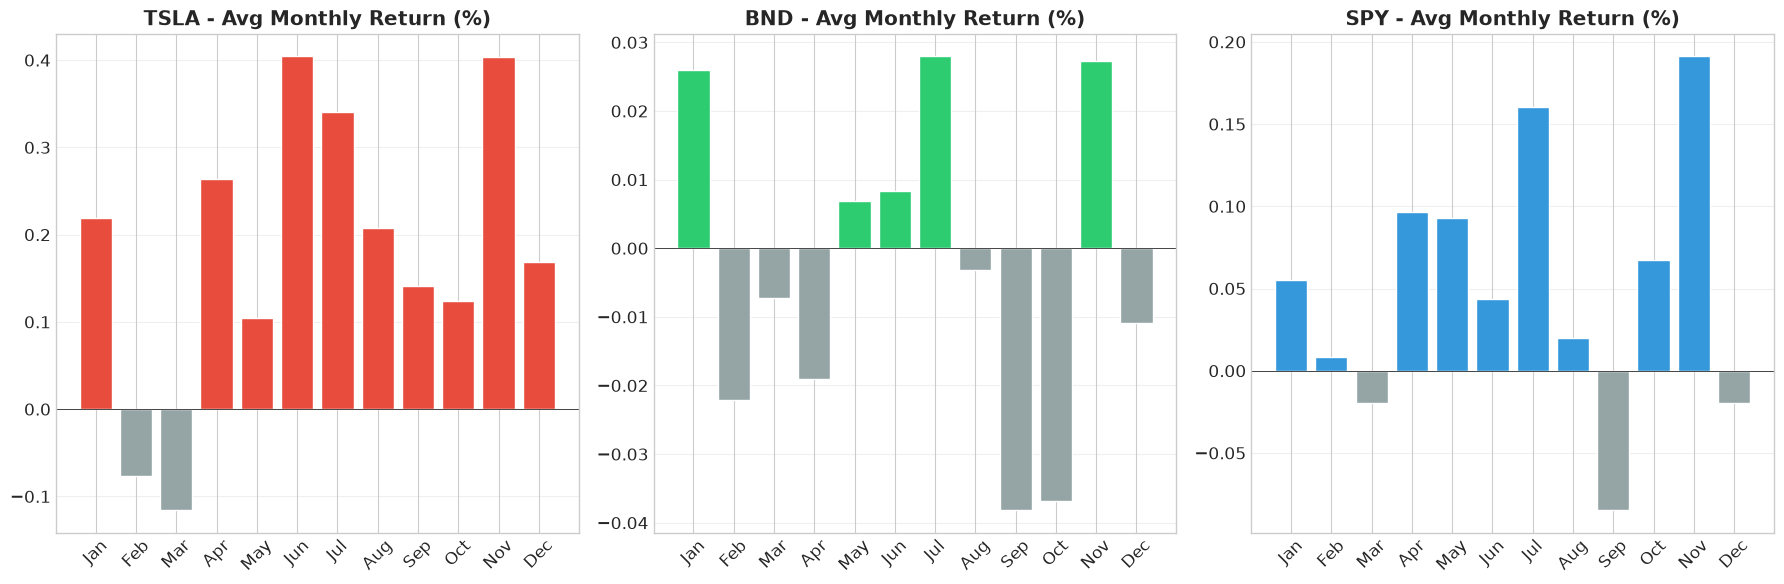

In [22]:
monthly_returns = daily_returns.copy()
monthly_returns['Month'] = monthly_returns.index.month

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for ax, ticker in zip(axes, tickers):
    monthly_avg = monthly_returns.groupby('Month')[ticker].mean() * 100
    bars = ax.bar(range(1, 13), monthly_avg, color=[colors[ticker] if v >= 0 else '#95a5a6'
                  for v in monthly_avg], edgecolor='white')
    ax.set_title(f'{ticker} - Avg Monthly Return (%)', fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, rotation=45)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'monthly_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Risk Metrics

### 6.1 Value at Risk (VaR)

VaR estimates the maximum expected loss over a given time period at a specific confidence level. We calculate both Historical VaR and Parametric VaR at the 95% confidence level.

In [23]:
confidence_level = 0.95

print("Value at Risk (VaR) Analysis - 95% Confidence Level")
print("=" * 60)
print("\nInterpretation: On any given day, there is a 5% chance that")
print("the loss will exceed the VaR value.")
print()

var_results = []
for ticker in tickers:
    returns = daily_returns[ticker]

    # Historical VaR
    hist_var = returns.quantile(1 - confidence_level)

    # Parametric VaR (assumes normal distribution)
    mean_ret = returns.mean()
    std_ret = returns.std()
    z_score = stats.norm.ppf(1 - confidence_level)
    param_var = mean_ret + z_score * std_ret

    var_results.append({
        'Asset': ticker,
        'Historical VaR (95%)': f'{hist_var*100:.3f}%',
        'Parametric VaR (95%)': f'{param_var*100:.3f}%',
        'Mean Daily Return': f'{mean_ret*100:.4f}%',
        'Daily Std Dev': f'{std_ret*100:.4f}%'
    })

    print(f"{ticker}:")
    print(f"  Historical VaR (95%): {hist_var*100:.3f}%")
    print(f"  Parametric VaR (95%): {param_var*100:.3f}%")
    print(f"  -> With a $10,000 investment, the max expected daily loss ")
    print(f"     is ${abs(hist_var)*10000:.2f} (historical) at 95% confidence.")
    print()

var_df = pd.DataFrame(var_results)
var_df

Value at Risk (VaR) Analysis - 95% Confidence Level

Interpretation: On any given day, there is a 5% chance that
the loss will exceed the VaR value.

TSLA:
  Historical VaR (95%): -5.166%
  Parametric VaR (95%): -5.744%
  -> With a $10,000 investment, the max expected daily loss 
     is $516.64 (historical) at 95% confidence.

BND:
  Historical VaR (95%): -0.508%
  Parametric VaR (95%): -0.560%
  -> With a $10,000 investment, the max expected daily loss 
     is $50.85 (historical) at 95% confidence.

SPY:
  Historical VaR (95%): -1.674%
  Parametric VaR (95%): -1.785%
  -> With a $10,000 investment, the max expected daily loss 
     is $167.41 (historical) at 95% confidence.



,Asset,Historical VaR (95%),Parametric VaR (95%),Mean Daily Return,Daily Std Dev
0,TSLA,-5.166%,-5.744%,0.1803%,3.6018%
1,BND,-0.508%,-0.560%,-0.0034%,0.3383%
2,SPY,-1.674%,-1.785%,0.0507%,1.1163%


### 6.2 Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return. A higher Sharpe Ratio indicates better risk-adjusted performance.

Formula: Sharpe Ratio = (Mean Return - Risk-Free Rate) / Standard Deviation of Returns

In [24]:
risk_free_rate_annual = 0.04  # ~4% annual (approximate current T-bill rate)
risk_free_rate_daily = risk_free_rate_annual / 252

print("Sharpe Ratio Analysis")
print(f"Risk-free rate: {risk_free_rate_annual*100:.1f}% annual ({risk_free_rate_daily*100:.4f}% daily)")
print("=" * 60)

sharpe_results = []
for ticker in tickers:
    returns = daily_returns[ticker]
    excess_returns = returns - risk_free_rate_daily

    daily_sharpe = excess_returns.mean() / excess_returns.std()
    annual_sharpe = daily_sharpe * np.sqrt(252)

    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)

    sharpe_results.append({
        'Asset': ticker,
        'Annualized Return': f'{annual_return*100:.2f}%',
        'Annualized Volatility': f'{annual_vol*100:.2f}%',
        'Sharpe Ratio (Annualized)': round(annual_sharpe, 4)
    })

    print(f"\n{ticker}:")
    print(f"  Annualized Return: {annual_return*100:.2f}%")
    print(f"  Annualized Volatility: {annual_vol*100:.2f}%")
    print(f"  Sharpe Ratio: {annual_sharpe:.4f}")

sharpe_df = pd.DataFrame(sharpe_results)
print("\n")
sharpe_df

Sharpe Ratio Analysis
Risk-free rate: 4.0% annual (0.0159% daily)

TSLA:
  Annualized Return: 45.42%
  Annualized Volatility: 57.18%
  Sharpe Ratio: 0.7245

BND:
  Annualized Return: -0.85%
  Annualized Volatility: 5.37%
  Sharpe Ratio: -0.9041

SPY:
  Annualized Return: 12.77%
  Annualized Volatility: 17.72%
  Sharpe Ratio: 0.4952




,Asset,Annualized Return,Annualized Volatility,Sharpe Ratio (Annualized)
0,TSLA,45.42%,57.18%,0.7245
1,BND,-0.85%,5.37%,-0.9041
2,SPY,12.77%,17.72%,0.4952


### 6.3 Additional Risk Metrics

In [25]:
print("Additional Risk Metrics")
print("=" * 60)

risk_metrics = []
for ticker in tickers:
    returns = daily_returns[ticker]
    cum_returns = (1 + returns).cumprod()
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    skewness = returns.skew()
    kurtosis_val = returns.kurtosis()

    # Sortino Ratio (uses downside deviation only)
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = (returns.mean() - risk_free_rate_daily) / downside_std * np.sqrt(252)

    risk_metrics.append({
        'Asset': ticker,
        'Max Drawdown': f'{max_drawdown*100:.2f}%',
        'Skewness': round(skewness, 4),
        'Kurtosis': round(kurtosis_val, 4),
        'Sortino Ratio': round(sortino, 4)
    })

    print(f"\n{ticker}:")
    print(f"  Max Drawdown: {max_drawdown*100:.2f}%")
    print(f"  Skewness: {skewness:.4f} ({'negative skew' if skewness < 0 else 'positive skew'})")
    print(f"  Kurtosis: {kurtosis_val:.4f} ({'heavy tails' if kurtosis_val > 3 else 'light tails'})")
    print(f"  Sortino Ratio: {sortino:.4f}")

risk_df = pd.DataFrame(risk_metrics)
print("\n")
risk_df

Additional Risk Metrics

TSLA:
  Max Drawdown: -73.63%
  Skewness: 0.2934 (positive skew)
  Kurtosis: 4.4670 (heavy tails)
  Sortino Ratio: 1.0734

BND:
  Max Drawdown: -23.96%
  Skewness: -0.9126 (negative skew)
  Kurtosis: 34.8551 (heavy tails)
  Sortino Ratio: -1.1382

SPY:
  Max Drawdown: -34.10%
  Skewness: -0.3095 (negative skew)
  Kurtosis: 13.8406 (heavy tails)
  Sortino Ratio: 0.6065




,Asset,Max Drawdown,Skewness,Kurtosis,Sortino Ratio
0,TSLA,-73.63%,0.2934,4.4670,1.0734
1,BND,-23.96%,-0.9126,34.8551,-1.1382
2,SPY,-34.10%,-0.3095,13.8406,0.6065


### 6.4 Cumulative Returns and Drawdown Visualization

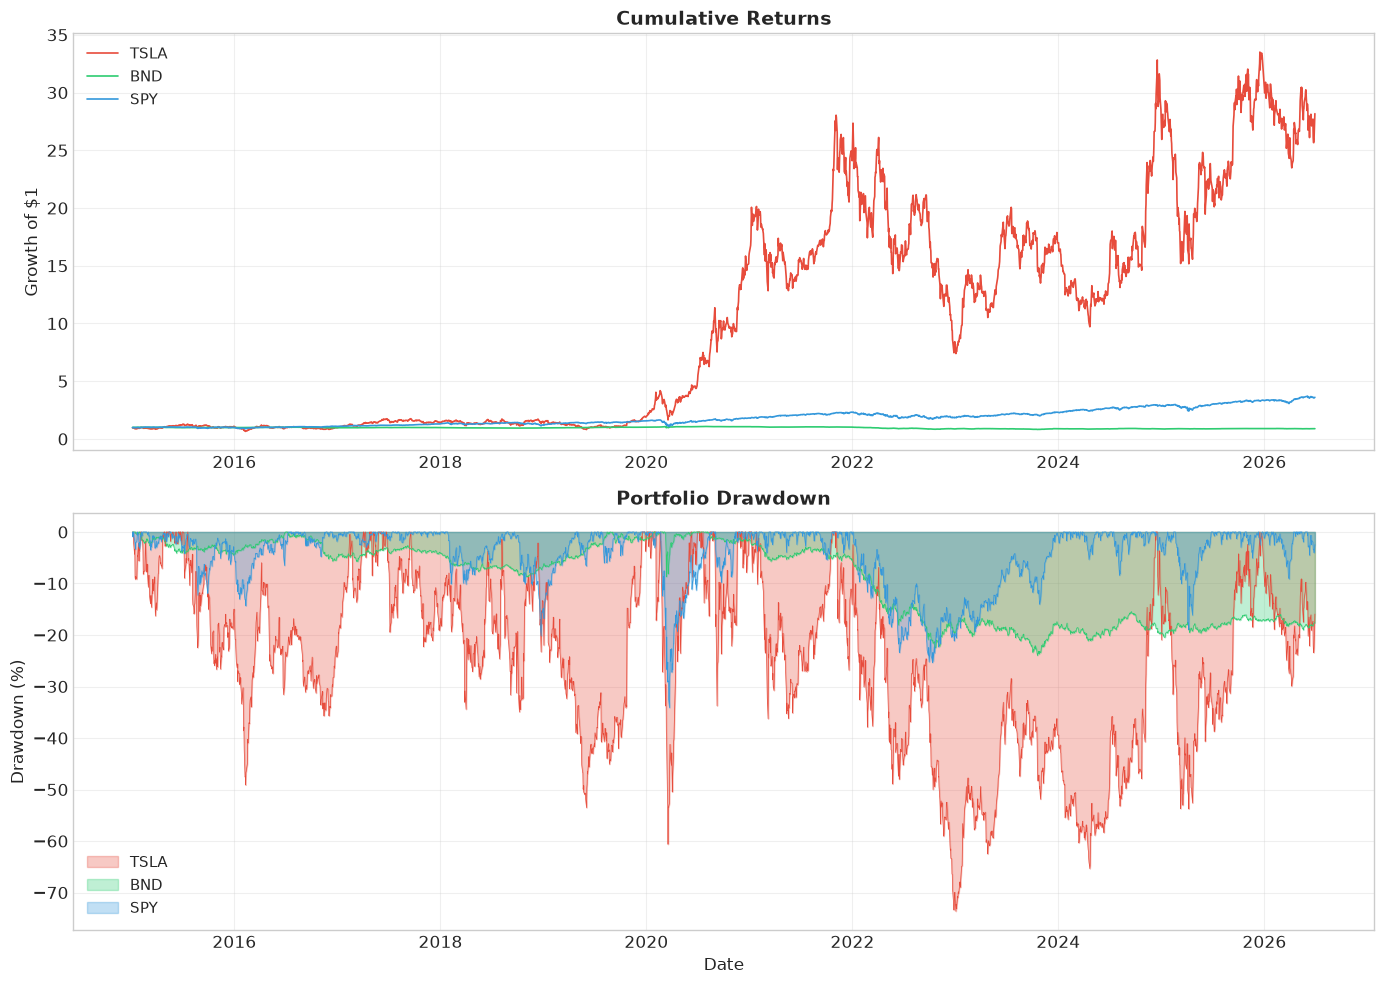

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Cumulative returns
for ticker in tickers:
    cum_ret = (1 + daily_returns[ticker]).cumprod()
    axes[0].plot(cum_ret.index, cum_ret, label=ticker, color=colors[ticker], linewidth=1.2)

axes[0].set_title('Cumulative Returns', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Drawdown
for ticker in tickers:
    cum_ret = (1 + daily_returns[ticker]).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    axes[1].fill_between(drawdown.index, drawdown * 100, alpha=0.3, color=colors[ticker], label=ticker)
    axes[1].plot(drawdown.index, drawdown * 100, color=colors[ticker], linewidth=0.5)

axes[1].set_title('Portfolio Drawdown', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'cumulative_returns_drawdown.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Insights Summary

### Data Quality
- Successfully extracted data for TSLA, BND, and SPY from January 2015 to June 2026
- All data types are appropriate (float64 for prices/volume, DatetimeIndex for dates)
- Missing values were handled using forward-fill and back-fill methods

### Price Trends
- **TSLA** shows an overall strong upward trend with high volatility, especially the massive rally in 2020 and significant drawdowns
- **BND** remains relatively flat with very low volatility, consistent with its role as a bond ETF providing stability
- **SPY** shows a steady upward trend reflecting broad market growth, with notable dips during market corrections (COVID-19 crash in March 2020, 2022 bear market)

### Volatility
- TSLA exhibits the highest daily return volatility, confirming its high-risk profile
- BND has the lowest volatility, making it suitable for risk reduction in portfolio construction
- SPY falls in between, providing moderate risk-reward exposure

### Stationarity
- **Closing prices are non-stationary** (fail ADF test) - typical of asset prices that follow trends
- **Daily returns are stationary** (pass ADF test) - first-order differencing removes the trend
- This confirms that ARIMA models will require d >= 1 for differencing

### Risk Metrics
- TSLA has the highest VaR, reflecting the largest potential daily losses
- BND offers the lowest risk across all metrics
- Sharpe Ratios help identify which assets provide the best risk-adjusted returns
- TSLA shows heavy-tailed return distributions (high kurtosis), indicating more extreme events than a normal distribution would predict

### Correlation
- Low to moderate correlations between assets suggest diversification benefits
- BND typically shows low or negative correlation with equity assets, making it an effective hedge